# MiNES v4 Output Visualization

Analyzes outputs from `scripts/mines_variance_fusion_v4.py`.
Segments live directly in `segment_root/` (no `forward/`/`reverse/` subdirs).
All cells run gracefully when output files are missing.

In [ ]:
from pathlib import Path

system_root = Path("../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0")
label = "mines_variance_fusion_v4_t1000"
seed = 123

run_root = system_root / "MINES" / label / "raw" / f"seed_{seed}"
print("run_root:", run_root)
print("exists:", run_root.exists())

run_root: ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123
exists: False


In [33]:
import json
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})


def read_csv_optional(path):
    """Load CSV as DataFrame; return empty DataFrame if missing."""
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        print(f"[loaded]  {path}  ({len(df)} rows, cols={list(df.columns)})")
        return df
    except Exception as e:
        print(f"[error]   {path}: {e}")
        return pd.DataFrame()


def read_json_optional(path):
    """Load JSON; return empty dict if missing."""
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return {}
    try:
        with open(path) as f:
            data = json.load(f)
        print(f"[loaded]  {path}")
        return data
    except Exception as e:
        print(f"[error]   {path}: {e}")
        return {}


def finite_numeric(df, col):
    """Return finite values of df[col] as a numpy array."""
    if df.empty or col not in df.columns:
        return np.array([])
    vals = pd.to_numeric(df[col], errors="coerce").values
    return vals[np.isfinite(vals)]

In [34]:
# Load all v4 output files
df_pmf        = read_csv_optional(run_root / "global_pmf.csv")
df_windows    = read_csv_optional(run_root / "windows.csv")
df_clusters   = read_csv_optional(run_root / "clusters.csv")
df_segments   = read_csv_optional(run_root / "segments.csv")
df_patches    = read_csv_optional(run_root / "patches.csv")
df_gen        = read_csv_optional(run_root / "generation_summary.csv")
df_overlap    = read_csv_optional(run_root / "neighbor_eq_overlap.csv")
df_refine     = read_csv_optional(run_root / "refinement_summary.csv")
df_ext        = read_csv_optional(run_root / "final_eq_extension_summary.csv")
df_quality    = read_csv_optional(run_root / "pmf_quality_vs_steps.csv")
df_budget     = read_csv_optional(run_root / "budget_ledger.csv")
fit_summary   = read_json_optional(run_root / "global_fit_summary.json")
run_summary   = read_json_optional(run_root / "mines_variance_fusion_summary.json")
run_ctx       = read_json_optional(system_root / "run_context.json")

[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123/global_pmf.csv
[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123/windows.csv
[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123/clusters.csv
[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123/segments.csv
[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/raw/seed_123/patches.csv
[missing] ../../data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/MINES/mines_variance_fusion_v4_t300/

## Plot 1: Global PMF

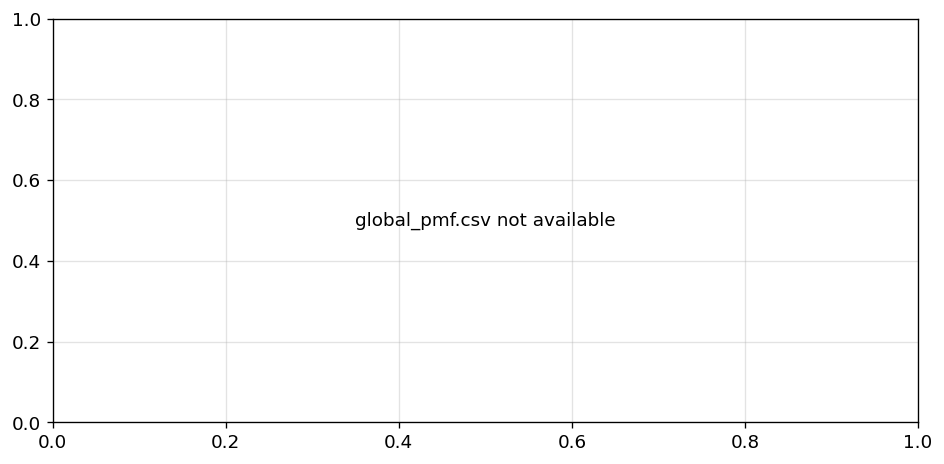

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))

if not df_pmf.empty and "x" in df_pmf.columns and "global_pmf" in df_pmf.columns:
    x = pd.to_numeric(df_pmf["x"], errors="coerce").values
    pmf = pd.to_numeric(df_pmf["global_pmf"], errors="coerce").values
    ok = np.isfinite(x) & np.isfinite(pmf)

    ax.plot(x[ok], pmf[ok], label="MiNES v4 global PMF", lw=2)

    if "global_variance" in df_pmf.columns:
        var = pd.to_numeric(df_pmf["global_variance"], errors="coerce").values
        std = np.sqrt(np.where(np.isfinite(var) & (var >= 0), var, np.nan))
        ok2 = ok & np.isfinite(std)
        ax.fill_between(x[ok2], pmf[ok2] - std[ok2], pmf[ok2] + std[ok2],
                        alpha=0.25, label="±1 σ")

    # Analytic PMF for 1D double well
    if run_ctx:
        try:
            pot = run_ctx["potential"]
            k0, x0, k1, x1, E1 = pot["k0"], pot["x0"], pot["k1"], pot["x1"], pot["E1"]
            kT = run_ctx.get("thermal_kT", 1.0)
            xa = np.linspace(x[ok].min(), x[ok].max(), 500)
            V = 0.5 * k0 * (xa - x0)**2 + E1 * np.exp(-0.5 * k1 * (xa - x1)**2)
            F_ana = -kT * np.log(np.exp(-V / kT))  # = V for deterministic
            F_ana -= F_ana.min()
            # Shift analytic to align with estimated PMF at first finite point
            ref_x = x[ok][np.argmin(np.abs(x[ok] - x0))]
            i_est = np.argmin(np.abs(x[ok] - ref_x))
            i_ana = np.argmin(np.abs(xa - ref_x))
            shift = pmf[ok][i_est] - F_ana[i_ana]
            ax.plot(xa, F_ana + shift, "--", color="gray", lw=1.5, label="Analytic PMF (shifted)")
        except Exception as e:
            print(f"Analytic PMF failed: {e}")

    ax.set_xlabel("x")
    ax.set_ylabel("PMF [kT]")
    ax.set_title(f"Global PMF — {label}")
    ax.legend()
else:
    ax.text(0.5, 0.5, "global_pmf.csv not available", ha="center", va="center",
            transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Plot 2: Global variance / standard deviation

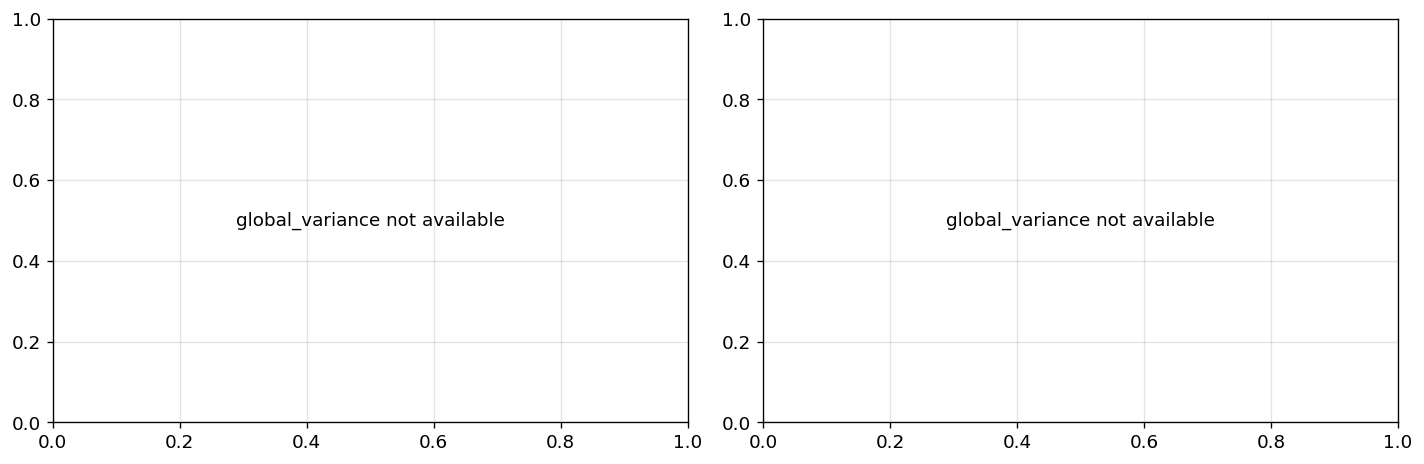

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not df_pmf.empty and "x" in df_pmf.columns and "global_variance" in df_pmf.columns:
    x = pd.to_numeric(df_pmf["x"], errors="coerce").values
    var = pd.to_numeric(df_pmf["global_variance"], errors="coerce").values
    ok = np.isfinite(x) & np.isfinite(var)

    axes[0].plot(x[ok], var[ok], color="C1")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("Variance")
    axes[0].set_title("Global PMF variance")

    std = np.sqrt(np.where(var >= 0, var, np.nan))
    ok2 = np.isfinite(x) & np.isfinite(std)
    axes[1].plot(x[ok2], std[ok2], color="C2")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("Std dev [kT]")
    axes[1].set_title("Global PMF std dev")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "global_variance not available", ha="center", va="center",
                transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Plot 3: EQ window map

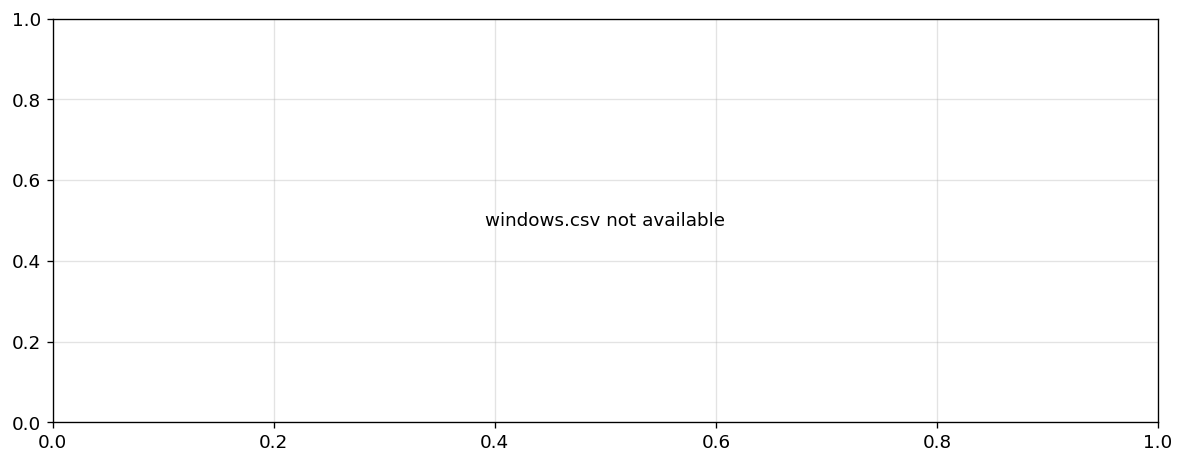

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))

if not df_windows.empty and "center_x" in df_windows.columns:
    colors = {"left": "C0", "right": "C1", "refine": "C2"}
    sides = df_windows["side"].unique() if "side" in df_windows.columns else ["unknown"]

    for side in sides:
        mask = df_windows["side"] == side if "side" in df_windows.columns else pd.Series([True] * len(df_windows))
        sub = df_windows[mask]
        cx = pd.to_numeric(sub["center_x"], errors="coerce")
        gen = pd.to_numeric(sub.get("generation", pd.Series([0] * len(sub))), errors="coerce").fillna(0)
        color = colors.get(str(side), "C3")
        ax.scatter(cx, gen, label=f"center_x ({side})", marker="o", s=60, color=color, zorder=3)

        if "mean_x" in sub.columns:
            mx = pd.to_numeric(sub["mean_x"], errors="coerce")
            ax.scatter(mx, gen, label=f"mean_x ({side})", marker="x", s=60, color=color, zorder=3)
            for c, m, g in zip(cx, mx, gen):
                if np.isfinite(c) and np.isfinite(m):
                    ax.plot([c, m], [g, g], color=color, alpha=0.3, lw=1)

    ax.set_xlabel("x")
    ax.set_ylabel("Generation")
    ax.set_title("EQ window positions (center_x vs mean_x)")
    ax.legend(fontsize=9, ncol=2)
else:
    ax.text(0.5, 0.5, "windows.csv not available", ha="center", va="center",
            transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Plot 4: Neighbor EQ overlap diagnostics

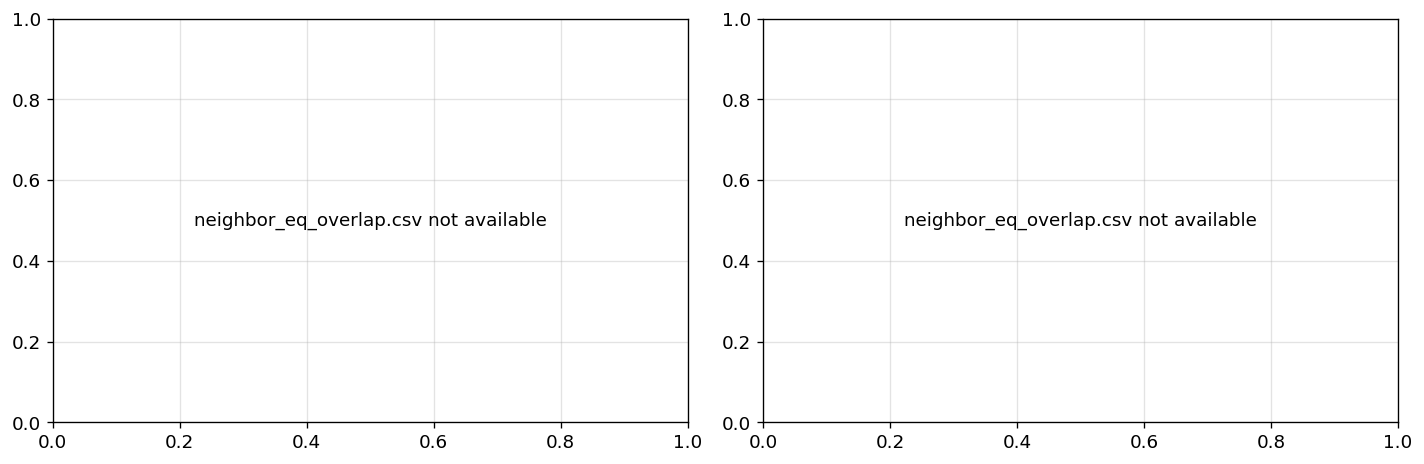

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not df_overlap.empty and "O_pair" in df_overlap.columns:
    # Sort by left window mean position if available
    if "left_mean_x" in df_overlap.columns:
        df_ov = df_overlap.sort_values("left_mean_x").reset_index(drop=True)
        midpoint = pd.to_numeric(df_ov["left_mean_x"], errors="coerce")
    else:
        df_ov = df_overlap.reset_index(drop=True)
        midpoint = df_ov.index

    overlap = pd.to_numeric(df_ov["O_pair"], errors="coerce")
    connected = df_ov["connected"].astype(str) == "True" if "connected" in df_ov.columns else pd.Series([True] * len(df_ov))

    colors_ov = ["C0" if c else "C3" for c in connected]
    axes[0].scatter(midpoint, overlap, c=colors_ov, s=50, zorder=3)
    axes[0].axhline(0.3, color="red", lw=1.5, ls="--", label="threshold 0.3")
    axes[0].set_xlabel("left_mean_x" if "left_mean_x" in df_ov.columns else "pair index")
    axes[0].set_ylabel("O_pair")
    axes[0].set_title("Pairwise BAR/MBAR EQ overlap")
    axes[0].legend()

    if "bar_delta_f_unc" in df_ov.columns:
        unc = pd.to_numeric(df_ov["bar_delta_f_unc"], errors="coerce")
        finite = np.isfinite(unc)
        if finite.any():
            axes[1].scatter(midpoint[finite], unc[finite], s=50, color="C4", zorder=3)
            axes[1].set_xlabel("left_mean_x" if "left_mean_x" in df_ov.columns else "pair index")
            axes[1].set_ylabel("BAR ΔF uncertainty")
            axes[1].set_title("BAR ΔF uncertainty")
        else:
            axes[1].text(0.5, 0.5, "bar_delta_f_unc all nan", ha="center", va="center",
                         transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, "bar_delta_f_unc not in overlap CSV", ha="center", va="center",
                     transform=axes[1].transAxes)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "neighbor_eq_overlap.csv not available", ha="center", va="center",
                transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Plot 5: Segment trajectory / protocol diagnostics

In [39]:
selected_segment = None   # set to a segment directory name to pick a specific one
n_traj_to_plot = 10

# Collect all segment directories recursively (no forward/ or reverse/ subdirs in v4)
def find_segment_dirs(root):
    """Return directories that contain protocol_forward.csv."""
    return sorted(p.parent for p in Path(root).rglob("protocol_forward.csv"))

seg_dirs = find_segment_dirs(run_root)
print(f"Found {len(seg_dirs)} segment directories")
for d in seg_dirs:
    print(" ", d.relative_to(run_root))

Found 0 segment directories


In [40]:
if seg_dirs:
    if selected_segment is not None:
        chosen = next((d for d in seg_dirs if d.name == selected_segment), seg_dirs[0])
    else:
        chosen = seg_dirs[0]
    print("Analyzing segment:", chosen.relative_to(run_root))

    # Protocol
    proto_fwd = chosen / "protocol_forward.csv"
    df_proto = read_csv_optional(proto_fwd)

    # Trajectories (neq_fwd_*.csv and neq_bwd_*.csv directly in segment dir)
    fwd_files = sorted(chosen.glob("neq_fwd_*.csv"))
    bwd_files = sorted(chosen.glob("neq_bwd_*.csv")) + sorted(chosen.glob("neq_rev_*.csv"))
    print(f"  Forward trajectories: {len(fwd_files)}")
    print(f"  Backward trajectories: {len(bwd_files)}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Protocol x0 and k
    if not df_proto.empty:
        x0_col = "x0" if "x0" in df_proto.columns else ("center" if "center" in df_proto.columns else None)
        k_col = "k" if "k" in df_proto.columns else None
        idx = np.arange(len(df_proto))
        if x0_col:
            axes[0, 0].plot(idx, pd.to_numeric(df_proto[x0_col], errors="coerce"))
            axes[0, 0].set_xlabel("Step index")
            axes[0, 0].set_ylabel("x0 (bias center)")
            axes[0, 0].set_title("Protocol: bias center")
        if k_col:
            axes[0, 1].plot(idx, pd.to_numeric(df_proto[k_col], errors="coerce"), color="C1")
            axes[0, 1].set_xlabel("Step index")
            axes[0, 1].set_ylabel("k")
            axes[0, 1].set_title("Protocol: spring constant")

    # Trajectory x traces
    for files, color, label in [(fwd_files, "C0", "fwd"), (bwd_files, "C3", "bwd")]:
        for i, f in enumerate(files[:n_traj_to_plot]):
            df_t = pd.read_csv(f)
            if "x" in df_t.columns:
                step_col = "step" if "step" in df_t.columns else None
                xx = np.arange(len(df_t)) if step_col is None else pd.to_numeric(df_t[step_col], errors="coerce")
                axes[1, 0].plot(xx, pd.to_numeric(df_t["x"], errors="coerce"),
                                color=color, alpha=0.4, lw=0.8,
                                label=label if i == 0 else None)
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("x")
    axes[1, 0].set_title(f"Trajectory x traces (up to {n_traj_to_plot} each)")
    axes[1, 0].legend()

    # Final work distributions
    for files, color, label in [(fwd_files, "C0", "forward W"), (bwd_files, "C3", "backward W")]:
        works = []
        for f in files:
            df_t = pd.read_csv(f)
            if "work" in df_t.columns:
                vals = pd.to_numeric(df_t["work"], errors="coerce").dropna().values
                if len(vals):
                    works.append(vals[-1])
        if works:
            axes[1, 1].hist(works, bins=20, alpha=0.6, color=color, label=label)
    axes[1, 1].set_xlabel("Final accumulated work")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].set_title("Work distributions")
    axes[1, 1].legend()

    plt.suptitle(f"Segment: {chosen.name}", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No segment directories found.")

No segment directories found.


## Plot 6: Patch coverage

In [41]:
# Search for pmf.csv files under patches/, refinement/, and final_eq_extension/
patch_pmf_files = []
for search_dir in ["patches", "refinement", "final_eq_extension"]:
    patch_pmf_files.extend(sorted((run_root / search_dir).rglob("pmf.csv")))

# Also check direct patches.csv listing
if not df_patches.empty and "patch_file" in df_patches.columns:
    for pf in df_patches["patch_file"].dropna():
        p = Path(pf)
        if not p.is_absolute():
            p = run_root / p
        if p.exists() and p not in patch_pmf_files:
            patch_pmf_files.append(p)

print(f"Found {len(patch_pmf_files)} patch PMF files")
for pf in patch_pmf_files:
    print(" ", pf.relative_to(run_root))

Found 0 patch PMF files


In [42]:
if patch_pmf_files:
    fig, ax = plt.subplots(figsize=(12, max(3, 0.4 * len(patch_pmf_files) + 1)))

    for row_idx, pf in enumerate(patch_pmf_files):
        df_p = pd.read_csv(pf)
        if "x" not in df_p.columns:
            continue
        x = pd.to_numeric(df_p["x"], errors="coerce").values
        pmf_col = next((c for c in ["pmf", "pmf_ref0", "global_pmf"] if c in df_p.columns), None)
        var_col = next((c for c in ["variance", "boot_var", "var_ref0", "global_variance"] if c in df_p.columns), None)
        finite_mask = np.zeros(len(x), dtype=bool)
        if pmf_col:
            finite_mask |= np.isfinite(pd.to_numeric(df_p[pmf_col], errors="coerce").values)
        if var_col:
            finite_mask |= np.isfinite(pd.to_numeric(df_p[var_col], errors="coerce").values)

        name = str(pf.relative_to(run_root))
        ax.scatter(x[finite_mask], [row_idx] * finite_mask.sum(),
                   s=4, color="C0", alpha=0.6)
        ax.text(x[finite_mask].max() + 0.1 if finite_mask.any() else 0,
                row_idx, name, fontsize=6, va="center")

    ax.set_xlabel("x")
    ax.set_ylabel("Patch index")
    ax.set_title("Patch PMF coverage")
    ax.set_yticks(range(len(patch_pmf_files)))
    ax.set_yticklabels([])
    plt.tight_layout()
    plt.show()
else:
    print("No patch PMF files found.")

No patch PMF files found.


## Plot 6b: NEQ patch anchor variance diagnostics

In [43]:
# Plot 6b: NEQ patch anchor variance diagnostics
# For each NEQ pmf.csv that has variance_left_anchor / variance_right_anchor columns,
# plot left-anchor, right-anchor, and min-anchor variances.

neq_anchor_files = [
    pf for pf in patch_pmf_files
    if pf.exists() and 'variance_left_anchor' in pd.read_csv(pf).columns
]
print(f'NEQ patches with anchor variance data: {len(neq_anchor_files)}')

for pf in neq_anchor_files:
    df_p = pd.read_csv(pf)
    x = pd.to_numeric(df_p['x'], errors='coerce').values
    v_min = pd.to_numeric(df_p['variance'], errors='coerce').values
    v_left = pd.to_numeric(df_p['variance_left_anchor'], errors='coerce').values
    v_right = pd.to_numeric(df_p['variance_right_anchor'], errors='coerce').values

    fig, ax = plt.subplots(figsize=(10, 4))
    ok = np.isfinite(x)
    if np.isfinite(v_left[ok]).any():
        ax.plot(x[ok], v_left[ok], label='left-anchor var', color='C0', lw=1.5)
    if np.isfinite(v_right[ok]).any():
        ax.plot(x[ok], v_right[ok], label='right-anchor var', color='C1', lw=1.5)
    if np.isfinite(v_min[ok]).any():
        ax.plot(x[ok], v_min[ok], label='min-anchor var (used for fusion)', color='C2',
                lw=2, ls='--')
    ax.set_xlabel('x')
    ax.set_ylabel('Bootstrap variance')
    ax.set_title(f'NEQ anchor variances: {pf.relative_to(run_root)}')
    ax.legend()
    plt.tight_layout()
    plt.show()


NEQ patches with anchor variance data: 0


## Plot 7: PMF quality vs budget

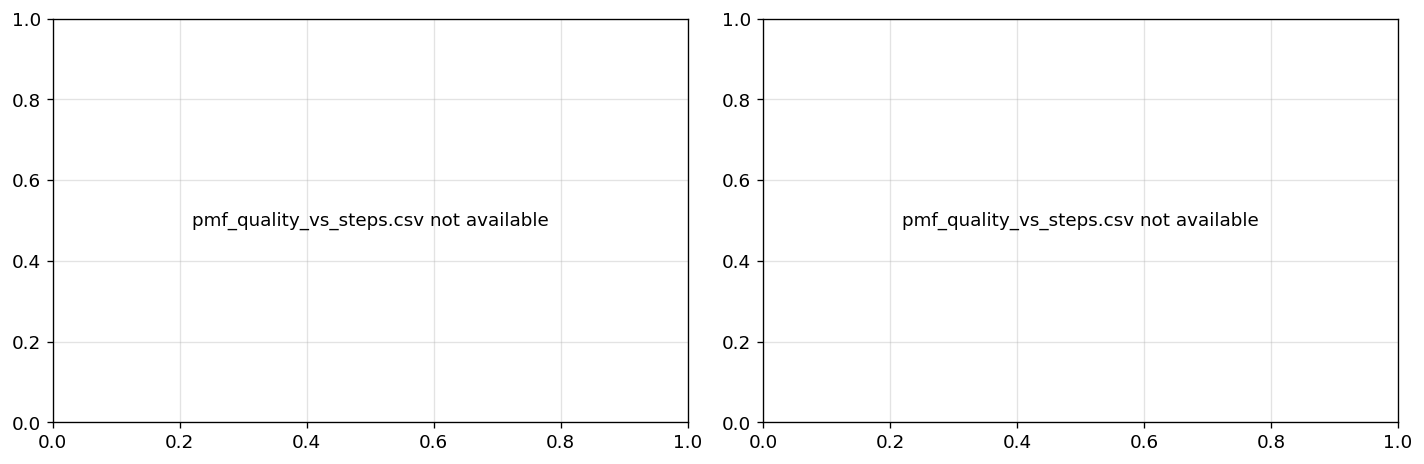

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not df_quality.empty and "used_steps" in df_quality.columns:
    steps = pd.to_numeric(df_quality["used_steps"], errors="coerce")

    if "coverage_fraction" in df_quality.columns:
        cov = pd.to_numeric(df_quality["coverage_fraction"], errors="coerce")
        ok = np.isfinite(steps) & np.isfinite(cov)
        axes[0].plot(steps[ok], cov[ok], marker="o", ms=4)
        axes[0].set_xlabel("Used steps")
        axes[0].set_ylabel("Coverage fraction")
        axes[0].set_title("Coverage vs budget")
        axes[0].axhline(1.0, color="gray", ls="--", lw=1)
    else:
        axes[0].text(0.5, 0.5, "coverage_fraction not in quality CSV",
                     ha="center", va="center", transform=axes[0].transAxes)

    if "max_mbar_ddf" in df_quality.columns:
        ddf = pd.to_numeric(df_quality["max_mbar_ddf"], errors="coerce")
        ok2 = np.isfinite(steps) & np.isfinite(ddf)
        if ok2.any():
            axes[1].semilogy(steps[ok2], ddf[ok2], marker="o", ms=4, color="C1")
            axes[1].set_xlabel("Used steps")
            axes[1].set_ylabel("max MBAR ddF")
            axes[1].set_title("MBAR uncertainty vs budget")
        else:
            axes[1].text(0.5, 0.5, "max_mbar_ddf all nan",
                         ha="center", va="center", transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, "max_mbar_ddf not in quality CSV",
                     ha="center", va="center", transform=axes[1].transAxes)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "pmf_quality_vs_steps.csv not available",
                ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Plot 8: Final EQ extension diagnostics

In [45]:
if not df_ext.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    rounds = np.arange(len(df_ext))

    if "max_mbar_ddf" in df_ext.columns:
        ddf = pd.to_numeric(df_ext["max_mbar_ddf"], errors="coerce")
        ok = np.isfinite(ddf)
        if ok.any():
            axes[0].semilogy(rounds[ok], ddf[ok], marker="o", ms=5)
            axes[0].set_xlabel("Extension round")
            axes[0].set_ylabel("max MBAR ddF")
            axes[0].set_title("MBAR uncertainty: EQ extension rounds")
        else:
            axes[0].text(0.5, 0.5, "max_mbar_ddf all nan", ha="center", va="center",
                         transform=axes[0].transAxes)

    steps_col = next((c for c in ["remaining_steps", "used_steps"] if c in df_ext.columns), None)
    if steps_col:
        sv = pd.to_numeric(df_ext[steps_col], errors="coerce")
        ok2 = np.isfinite(sv)
        axes[1].plot(rounds[ok2], sv[ok2], marker="o", ms=5, color="C2")
        axes[1].set_xlabel("Extension round")
        axes[1].set_ylabel(steps_col)
        axes[1].set_title(f"{steps_col} vs round")
    else:
        axes[1].text(0.5, 0.5, "No step column in extension CSV", ha="center", va="center",
                     transform=axes[1].transAxes)

    # Print stop reason from last row
    if "stop_reason" in df_ext.columns:
        last_reason = df_ext["stop_reason"].dropna().iloc[-1] if not df_ext["stop_reason"].dropna().empty else "n/a"
        print(f"Stop reason (last row): {last_reason}")

    plt.tight_layout()
    plt.show()
else:
    print("final_eq_extension_summary.csv not available — EQ extension may not have run.")

final_eq_extension_summary.csv not available — EQ extension may not have run.


## Run summary

In [46]:
if run_summary:
    for k, v in run_summary.items():
        print(f"  {k}: {v}")
else:
    print("mines_variance_fusion_summary.json not available.")

mines_variance_fusion_summary.json not available.


## Plot 9: EQ distributions by generation and refinement

In [47]:
def _gauss_kde(xs, x_eval, bw=None):
    """Gaussian KDE without scipy. bw=None uses Silverman's rule."""
    xs = np.asarray(xs, dtype=float)
    xs = xs[np.isfinite(xs)]
    if len(xs) < 2:
        return np.zeros(len(x_eval), dtype=float)
    if bw is None:
        bw = max(1.06 * np.std(xs, ddof=1) * len(xs) ** -0.2, 1e-6)
    diff = (np.asarray(x_eval, dtype=float)[:, None] - xs[None, :]) / bw
    return np.mean(np.exp(-0.5 * diff ** 2), axis=1) / (bw * np.sqrt(2.0 * np.pi))


# ---- Find eq_tail.csv files (one per window directory) ----
tail_paths = {p.parent.name: p for p in run_root.rglob("eq_tail.csv")}
print(f"Found {len(tail_paths)} EQ window tail files")

# ---- Window metadata lookup ----
win_meta = {}
if not df_windows.empty:
    for _, wrow in df_windows.iterrows():
        wname = str(wrow.get("name", ""))
        win_meta[wname] = {
            "generation": int(pd.to_numeric(wrow.get("generation", -1), errors="coerce")),
            "side":      str(wrow.get("side", "unknown")),
            "center_x":  float(pd.to_numeric(wrow.get("center_x", np.nan), errors="coerce")),
            "mean_x":    float(pd.to_numeric(wrow.get("mean_x",   np.nan), errors="coerce")),
            "std_x":     float(pd.to_numeric(wrow.get("std_x",    np.nan), errors="coerce")),
            "k":         float(pd.to_numeric(wrow.get("k",        np.nan), errors="coerce")),
        }

# ---- Load tail samples ----
records = []
for wname, tpath in sorted(tail_paths.items()):
    meta = win_meta.get(wname, {"generation": -1, "side": "unknown",
                                "center_x": np.nan, "mean_x": np.nan,
                                "std_x": np.nan, "k": np.nan})
    try:
        xs = pd.to_numeric(pd.read_csv(tpath)["x"], errors="coerce").dropna().values
        xs = xs[np.isfinite(xs)]
    except Exception:
        xs = np.array([])
    records.append({"name": wname, "xs": xs, **meta})

exploration = sorted(
    [r for r in records if r["side"] in ("left", "right")],
    key=lambda r: (r["generation"], r["side"])
)
refinement = sorted(
    [r for r in records if r["side"] == "refine"],
    key=lambda r: r["name"]
)
print(f"  Exploration: {len(exploration)} windows   Refinement: {len(refinement)} windows")

if not records or all(len(r["xs"]) == 0 for r in records):
    print("No EQ tail samples found — run a simulation first.")
else:
    # KDE evaluation grid
    all_xs = np.concatenate([r["xs"] for r in records if len(r["xs"]) > 0])
    x_lo = np.nanmin(all_xs) - 0.5
    x_hi = np.nanmax(all_xs) + 0.5
    x_grid = np.linspace(x_lo, x_hi, 600)

    # PMF reference arrays (finite values only)
    pmf_ref_x = pmf_ref_y = pmf_ref_y_norm = np.array([])
    if not df_pmf.empty and "x" in df_pmf.columns and "global_pmf" in df_pmf.columns:
        _px = pd.to_numeric(df_pmf["x"],          errors="coerce").values
        _py = pd.to_numeric(df_pmf["global_pmf"], errors="coerce").values
        _ok = np.isfinite(_px) & np.isfinite(_py)
        pmf_ref_x = _px[_ok]
        pmf_ref_y = _py[_ok]
        _rng = pmf_ref_y.max() - pmf_ref_y.min()
        pmf_ref_y_norm = (pmf_ref_y - pmf_ref_y.min()) / max(_rng, 1e-10)

    def _draw_pmf_bg(ax):
        """Normalized PMF as a faint gray fill for ridge-plot backgrounds."""
        if len(pmf_ref_x):
            ax.fill_between(pmf_ref_x, pmf_ref_y_norm, alpha=0.08, color="gray", zorder=0)
            ax.plot(pmf_ref_x, pmf_ref_y_norm, color="gray", lw=0.8, alpha=0.3, zorder=0)

    row_h    = 1.5
    gen_cmap = cm.viridis
    ref_cmap = cm.plasma
    side_ls  = {"left": "-", "right": "--"}

    # =========================================================
    # Panel A: exploration windows, one ridge per window
    # =========================================================
    n_gen   = max((r["generation"] for r in exploration), default=0) + 1
    n_rows_a = max(len(exploration), 1)
    fig_a, ax_a = plt.subplots(figsize=(12, max(4, 0.55 * n_rows_a + 1.5)))
    _draw_pmf_bg(ax_a)

    yticks_a, ylabels_a = [], []
    for i, r in enumerate(exploration):
        y_base = i * row_h
        color  = gen_cmap(r["generation"] / max(n_gen - 1, 1))
        ls     = side_ls.get(r["side"], "-")

        if len(r["xs"]) >= 3:
            dens = _gauss_kde(r["xs"], x_grid)
            if dens.max() > 0:
                dens = dens / dens.max() * row_h * 0.88
            ax_a.fill_between(x_grid, y_base, y_base + dens,
                              alpha=0.28, color=color, zorder=2)
            ax_a.plot(x_grid, y_base + dens,
                      color=color, lw=1.2, ls=ls, alpha=0.9, zorder=3)
        if np.isfinite(r["mean_x"]):
            ax_a.plot([r["mean_x"], r["mean_x"]],
                      [y_base, y_base + row_h * 0.72],
                      color=color, lw=1.0, ls=":", alpha=0.75, zorder=4)

        yticks_a.append(y_base + row_h * 0.35)
        ylabels_a.append(
            f"gen{r['generation']} {r['side'][0].upper()}  σ={r['std_x']:.3f}"
        )

    ax_a.set_yticks(yticks_a)
    ax_a.set_yticklabels(ylabels_a, fontsize=8)
    ax_a.set_xlim(x_lo, x_hi)
    ax_a.set_xlabel("x")
    ax_a.set_title(
        f"Exploration EQ distributions by generation — {label}\n"
        "solid = left side  |  dashed = right side  |  dotted = mean_x"
    )
    sm_a = plt.cm.ScalarMappable(cmap=gen_cmap,
                                 norm=plt.Normalize(0, max(n_gen - 1, 1)))
    sm_a.set_array([])
    plt.colorbar(sm_a, ax=ax_a, label="Generation", shrink=0.7, pad=0.01)
    plt.tight_layout()
    plt.show()

    # =========================================================
    # Panel B: refinement windows, one ridge per window
    # =========================================================
    n_rows_b = max(len(refinement), 1)
    fig_b, ax_b = plt.subplots(figsize=(12, max(4, 0.55 * n_rows_b + 1.5)))
    _draw_pmf_bg(ax_b)

    if refinement:
        yticks_b, ylabels_b = [], []
        n_ref = len(refinement)
        for i, r in enumerate(refinement):
            y_base = i * row_h
            color  = ref_cmap(i / max(n_ref - 1, 1))

            if len(r["xs"]) >= 3:
                dens = _gauss_kde(r["xs"], x_grid)
                if dens.max() > 0:
                    dens = dens / dens.max() * row_h * 0.88
                ax_b.fill_between(x_grid, y_base, y_base + dens,
                                  alpha=0.32, color=color, zorder=2)
                ax_b.plot(x_grid, y_base + dens,
                          color=color, lw=1.2, alpha=0.9, zorder=3)
            if np.isfinite(r["mean_x"]):
                ax_b.plot([r["mean_x"], r["mean_x"]],
                          [y_base, y_base + row_h * 0.72],
                          color=color, lw=1.0, ls=":", alpha=0.75, zorder=4)

            yticks_b.append(y_base + row_h * 0.35)
            ylabels_b.append(f"{r['name']}  σ={r['std_x']:.3f}")

        ax_b.set_yticks(yticks_b)
        ax_b.set_yticklabels(ylabels_b, fontsize=8)
    else:
        ax_b.text(0.5, 0.5, "No refinement windows found",
                  ha="center", va="center", transform=ax_b.transAxes, fontsize=12)

    ax_b.set_xlim(x_lo, x_hi)
    ax_b.set_xlabel("x")
    ax_b.set_title(
        f"Refinement EQ distributions — {label}\n"
        "dotted = mean_x  |  gray fill = global PMF (normalized)"
    )
    plt.tight_layout()
    plt.show()

    # =========================================================
    # Panel C: all windows overlaid, colored by side/type
    # =========================================================
    side_color = {"left": "C0", "right": "C1", "refine": "C2"}

    fig_c, ax_c = plt.subplots(figsize=(12, 4))

    # PMF on a twin y-axis (raw kT values)
    if len(pmf_ref_x):
        ax_c2 = ax_c.twinx()
        ax_c2.plot(pmf_ref_x, pmf_ref_y, color="gray", lw=1.2, alpha=0.35, zorder=0)
        ax_c2.set_ylabel("PMF [kT]", color="gray", fontsize=9)
        ax_c2.tick_params(axis="y", labelcolor="gray", labelsize=8)

    plotted_sides = set()
    for r in records:
        if len(r["xs"]) < 3:
            continue
        color = side_color.get(r["side"], "C3")
        alpha = 0.55 if r["side"] == "refine" else 0.30
        lw    = 1.8  if r["side"] == "refine" else 1.0
        dens  = _gauss_kde(r["xs"], x_grid)
        if dens.max() > 0:
            dens = dens / dens.max()
        win_label = r["side"] if r["side"] not in plotted_sides else None
        ax_c.plot(x_grid, dens, color=color, lw=lw, alpha=alpha,
                  label=win_label, zorder=3)
        plotted_sides.add(r["side"])
        if np.isfinite(r["mean_x"]):
            ax_c.axvline(r["mean_x"], color=color, lw=0.5, alpha=0.20, zorder=2)

    ax_c.set_xlabel("x")
    ax_c.set_ylabel("Normalized density")
    ax_c.set_title(
        f"All EQ window distributions overlaid — {label}\n"
        "blue=left  |  orange=right  |  green=refinement  |  gray=PMF"
    )
    ax_c.legend(title="side", fontsize=9)
    plt.tight_layout()
    plt.show()


Found 0 EQ window tail files
  Exploration: 0 windows   Refinement: 0 windows
No EQ tail samples found — run a simulation first.


## Plot 10: MTS/HS PMF from each bidirectional NES segment

In [ ]:
# ---- Find all NEQ_MTS patch directories via patch_summary.json ----
neq_patch_dirs = []
for psf in sorted(run_root.rglob("patch_summary.json")):
    try:
        with open(psf) as f:
            meta = json.load(f)
    except Exception:
        continue
    if str(meta.get("kind", "")) == "NEQ_MTS":
        neq_patch_dirs.append((psf.parent, meta))

print(f"Found {len(neq_patch_dirs)} NEQ_MTS patch directories")


def _src_label(patch_dir):
    """Return 'explore/genN' or 'refine/round_NNN' inferred from the path."""
    parts = patch_dir.parts
    if "refinement" in parts:
        ridx = parts.index("refinement")
        rnd = parts[ridx + 1] if ridx + 1 < len(parts) else "?"
        return f"refine/{rnd}"
    if "patches" in parts:
        pidx = parts.index("patches")
        gen = parts[pidx + 1] if pidx + 1 < len(parts) else "?"
        return f"explore/{gen}"
    return "unknown"


# ---- Global PMF arrays for alignment ----
gx = gy = np.array([])
if not df_pmf.empty and "x" in df_pmf.columns and "global_pmf" in df_pmf.columns:
    _px = pd.to_numeric(df_pmf["x"],          errors="coerce").values
    _py = pd.to_numeric(df_pmf["global_pmf"], errors="coerce").values
    _ok = np.isfinite(_px) & np.isfinite(_py)
    gx, gy = _px[_ok], _py[_ok]


def _align_offset(x_patch, pmf_patch, gx, gy):
    """Shift (scalar) so patch aligns with global PMF: mean(global - patch) over overlap."""
    if len(gx) == 0:
        return 0.0
    interp_g = np.interp(x_patch, gx, gy, left=np.nan, right=np.nan)
    ok = np.isfinite(pmf_patch) & np.isfinite(interp_g)
    return float(np.nanmean(interp_g[ok] - pmf_patch[ok])) if ok.sum() >= 2 else 0.0


if not neq_patch_dirs:
    print("No NEQ_MTS patches found — run a simulation first.")
else:
    # ---- Load each patch ----
    patches = []
    for patch_dir, meta in neq_patch_dirs:
        pmf_file = patch_dir / "pmf.csv"
        if not pmf_file.exists():
            continue
        try:
            df_p = pd.read_csv(pmf_file)
        except Exception:
            continue
        if "x" not in df_p.columns or "pmf" not in df_p.columns:
            continue

        x_p   = pd.to_numeric(df_p["x"],   errors="coerce").values
        pmf_p = pd.to_numeric(df_p["pmf"], errors="coerce").values
        var_p = pd.to_numeric(df_p.get("variance",
                              pd.Series([np.nan] * len(df_p))), errors="coerce").values
        cov_p = (pd.to_numeric(df_p.get("coverage",
                               pd.Series([0] * len(df_p))), errors="coerce")
                 .fillna(0).values > 0)

        ok  = np.isfinite(x_p) & np.isfinite(pmf_p)
        src = _src_label(patch_dir)
        off = _align_offset(x_p[ok], pmf_p[ok], gx, gy)

        patches.append({
            "name":       patch_dir.name,
            "src":        src,
            "cft_solved": bool(meta.get("cft_solved", False)),
            "mts_solved": bool(meta.get("mts_solved", False)),
            "delta_f":    meta.get("delta_f"),
            "left_ref_x":  meta.get("left_reference_x", np.nan),
            "right_ref_x": meta.get("right_reference_x", np.nan),
            "n_boot":     meta.get("n_boot_used", meta.get("n_boot", 0)),
            "x": x_p, "pmf": pmf_p, "var": var_p, "cov": cov_p,
            "ok": ok, "offset": off,
        })

    print(f"Loaded {len(patches)} patch PMF files\n")

    # ---- Summary table ----
    header = f"  {'Segment':<35} {'Source':<22} {'CFT':>4} {'MTS':>4} {'ΔF':>10} {'cov pts':>8}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for p in patches:
        df_str  = (f"{float(p['delta_f']):.4f}"
                   if p["delta_f"] is not None and np.isfinite(float(p["delta_f"]))
                   else "n/a")
        cov_pts = int(np.sum(p["cov"] & p["ok"]))
        print(f"  {p['name']:<35} {p['src']:<22} {int(p['cft_solved']):>4} "
              f"{int(p['mts_solved']):>4} {df_str:>10} {cov_pts:>8}")

    # ---- Color mapping: explore → viridis, refine → plasma ----
    explore_srcs = sorted(set(p["src"] for p in patches if p["src"].startswith("explore/")))
    refine_srcs  = sorted(set(p["src"] for p in patches if p["src"].startswith("refine/")))

    def _patch_color(p):
        src = p["src"]
        if src in explore_srcs:
            return cm.viridis(explore_srcs.index(src) / max(len(explore_srcs) - 1, 1))
        if src in refine_srcs:
            return cm.plasma(refine_srcs.index(src) / max(len(refine_srcs) - 1, 1))
        return "gray"

    # =========================================================
    # Figure A: all MTS-solved patches overlaid on global PMF
    # =========================================================
    from matplotlib.lines import Line2D

    fig_a, ax_a = plt.subplots(figsize=(12, 5))

    if len(gx):
        ax_a.plot(gx, gy, "k-", lw=2.0, alpha=0.85, label="global PMF", zorder=10)

    for p in patches:
        if not p["mts_solved"]:
            continue
        x_p, pmf_p, var_p = p["x"], p["pmf"], p["var"]
        ok, off = p["ok"], p["offset"]
        color   = _patch_color(p)

        ax_a.plot(x_p[ok], pmf_p[ok] + off, color=color, lw=1.2, alpha=0.80, zorder=4)

        std_p   = np.sqrt(np.where(np.isfinite(var_p) & (var_p >= 0), var_p, np.nan))
        ok_std  = ok & np.isfinite(std_p)
        if ok_std.any():
            ax_a.fill_between(x_p[ok_std],
                              pmf_p[ok_std] + off - std_p[ok_std],
                              pmf_p[ok_std] + off + std_p[ok_std],
                              alpha=0.12, color=color, zorder=3)

        cov_ok = p["cov"] & ok
        if cov_ok.any():
            ax_a.axvspan(x_p[cov_ok].min(), x_p[cov_ok].max(),
                         alpha=0.04, color=color, zorder=1)

        for ref_x in [p["left_ref_x"], p["right_ref_x"]]:
            if ref_x is not None and np.isfinite(float(ref_x)):
                ax_a.axvline(float(ref_x), color=color, lw=0.6, ls=":", alpha=0.40, zorder=2)

    leg = []
    if len(gx):
        leg.append(Line2D([0], [0], color="k", lw=2, label="global PMF"))
    for i, src in enumerate(explore_srcs):
        leg.append(Line2D([0], [0], lw=1.5, label=src,
                          color=cm.viridis(i / max(len(explore_srcs) - 1, 1))))
    for i, src in enumerate(refine_srcs):
        leg.append(Line2D([0], [0], lw=1.5, label=src,
                          color=cm.plasma(i / max(len(refine_srcs) - 1, 1))))
    ax_a.legend(handles=leg, fontsize=8, ncol=3, loc="upper left")
    ax_a.set_xlabel("x")
    ax_a.set_ylabel("PMF [kT]")
    ax_a.set_title(
        f"MTS/HS PMF — all bidirectional NES segments overlaid — {label}\n"
        "Curves shifted to align with global PMF  |  shading = ±1σ bootstrap  |  "
        "dotted = boundary ref_x  |  faint band = MTS coverage"
    )
    plt.tight_layout()
    plt.show()

    # =========================================================
    # Figure B: one panel per MTS-solved patch
    # =========================================================
    solved = [p for p in patches if p["mts_solved"]]
    if not solved:
        print("No MTS-solved patches — nothing to show individually.")
    else:
        ncols = min(3, len(solved))
        nrows = (len(solved) + ncols - 1) // ncols
        fig_b, axes_b = plt.subplots(nrows, ncols,
                                     figsize=(5 * ncols, 3.8 * nrows),
                                     squeeze=False)

        for idx, p in enumerate(solved):
            ax2 = axes_b[idx // ncols][idx % ncols]
            x_p, pmf_p, var_p = p["x"], p["pmf"], p["var"]
            ok, off = p["ok"], p["offset"]
            color   = _patch_color(p)

            if len(gx):
                ax2.plot(gx, gy, color="lightgray", lw=1.5, zorder=0, label="global PMF")

            ax2.plot(x_p[ok], pmf_p[ok] + off, color=color, lw=1.5, zorder=4, label="MTS")

            std_p  = np.sqrt(np.where(np.isfinite(var_p) & (var_p >= 0), var_p, np.nan))
            ok_std = ok & np.isfinite(std_p)
            if ok_std.any():
                ax2.fill_between(x_p[ok_std],
                                 pmf_p[ok_std] + off - std_p[ok_std],
                                 pmf_p[ok_std] + off + std_p[ok_std],
                                 alpha=0.22, color=color, label="±1σ")

            for ref_x in [p["left_ref_x"], p["right_ref_x"]]:
                if ref_x is not None and np.isfinite(float(ref_x)):
                    ax2.axvline(float(ref_x), color="k", lw=0.8, ls="--", alpha=0.45)

            df_str = (f"ΔF={float(p['delta_f']):.3f}"
                      if p["delta_f"] is not None and np.isfinite(float(p["delta_f"]))
                      else "ΔF=n/a")
            ax2.set_title(f"{p['name']}\n{p['src']}  {df_str}", fontsize=8)
            ax2.set_xlabel("x", fontsize=8)
            ax2.set_ylabel("PMF [kT]", fontsize=8)
            ax2.tick_params(labelsize=7)
            ax2.legend(fontsize=7, loc="upper left")

        for idx in range(len(solved), nrows * ncols):
            axes_b[idx // ncols][idx % ncols].set_visible(False)

        plt.suptitle(
            f"MTS/HS PMF — individual patches — {label}\n"
            "gray = global PMF  |  dashed = boundary ref_x",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()
